# 🎓 Smart Classroom Attention Analyzer
### Multi-Label Student Behaviour Detection using EfficientNet-B0

**Dataset:** Student Behaviour Detection (Roboflow) — 4,065 images, 12 behaviour classes  
**Task:** Multi-label image classification (each image can have multiple behaviours simultaneously)  
**Model:** EfficientNet-B0 with Transfer Learning

---
**Labels:** `Using_phone`, `bend`, `book`, `bow_head`, `hand-raising`, `phone`, `raise_head`, `reading`, `sleep`, `turn_head`, `upright`, `writing`

## ✅ Step 1 — Check GPU & Install Dependencies

In [ ]:
# Check if GPU is available
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No GPU found — Go to Runtime > Change runtime type > T4 GPU")

# Install any missing packages
!pip install -q scikit-learn matplotlib seaborn Pillow torchvision

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 📁 Step 2 — Upload & Extract Dataset

Upload your zip file: `Student_Behaviour_Detection_v6i_multiclass.zip`

In [ ]:
from google.colab import files
import zipfile, os

# Upload the zip file
print("📂 Please upload your zip file...")
uploaded = files.upload()

# Extract it
zip_name = list(uploaded.keys())[0]
DATASET_DIR = "/content/dataset"

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(DATASET_DIR)

print(f"\n✅ Extracted to {DATASET_DIR}")
print("Contents:", os.listdir(DATASET_DIR))

📂 Please upload your zip file...


Saving Student Behaviour Detection.v6i.multiclass.zip to Student Behaviour Detection.v6i.multiclass.zip

✅ Extracted to /content/dataset
Contents: ['train', 'README.roboflow.txt', 'test', 'valid', 'README.dataset.txt']


## 🔍 Step 3 — Explore & Understand the Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# Load the CSVs
train_df = pd.read_csv(os.path.join(DATASET_DIR, 'train', '_classes.csv'))
valid_df = pd.read_csv(os.path.join(DATASET_DIR, 'valid', '_classes.csv'))
test_df  = pd.read_csv(os.path.join(DATASET_DIR, 'test',  '_classes.csv'))

# Clean column names (strip whitespace)
for df in [train_df, valid_df, test_df]:
    df.columns = df.columns.str.strip()

# Get class labels (everything except 'filename')
CLASS_NAMES = [c for c in train_df.columns if c != 'filename']
NUM_CLASSES = len(CLASS_NAMES)

print(f"📊 Dataset Split:")
print(f"  Train:      {len(train_df)} images")
print(f"  Validation: {len(valid_df)} images")
print(f"  Test:       {len(test_df)} images")
print(f"  Total:      {len(train_df)+len(valid_df)+len(test_df)} images")
print(f"\n🏷️  Classes ({NUM_CLASSES}): {CLASS_NAMES}")

train_df.head()

📊 Dataset Split:
  Train:      3192 images
  Validation: 581 images
  Test:       292 images
  Total:      4065 images

🏷️  Classes (12): ['Using_phone', 'bend', 'book', 'bow_head', 'hand-raising', 'phone', 'raise_head', 'reading', 'sleep', 'turn_head', 'upright', 'writing']


,filename,Using_phone,bend,book,bow_head,hand-raising,phone,raise_head,reading,sleep,turn_head,upright,writing
0,00217_jpg.rf.140760cb08ab70fa3df28b7ee8ebac7c.jpg,0,0,1,1,0,1,0,1,0,1,1,0
1,00030009_png.rf.14a518595d78a9c159208765352c8a...,0,0,0,0,1,0,0,0,0,0,0,0
2,00000008_jpg.rf.1271a69564161fba2f16e2b8262a4f...,1,1,1,1,0,1,1,0,1,0,1,0
3,00000306_jpg.rf.149268fcf99c009d71d74efe47a02c...,1,1,1,1,0,1,1,1,0,0,1,0
4,0026010_png.rf.144635eb7b2bae95efcac593fc511f9...,0,0,0,0,0,0,0,0,0,0,0,1


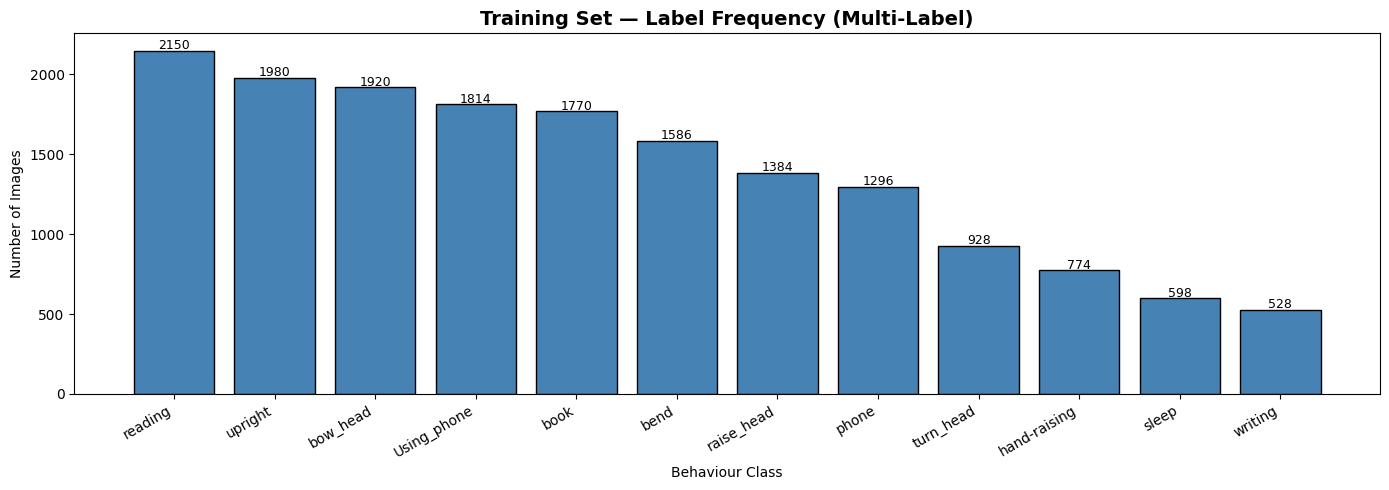


Label counts:
reading         2150
upright         1980
bow_head        1920
Using_phone     1814
book            1770
bend            1586
raise_head      1384
phone           1296
turn_head        928
hand-raising     774
sleep            598
writing          528
dtype: int64


In [ ]:
# Visualise label distribution in training set
label_counts = train_df[CLASS_NAMES].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
bars = plt.bar(label_counts.index, label_counts.values, color='steelblue', edgecolor='black')
plt.title('Training Set — Label Frequency (Multi-Label)', fontsize=14, fontweight='bold')
plt.xlabel('Behaviour Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(int(val)), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nLabel counts:")
print(label_counts)

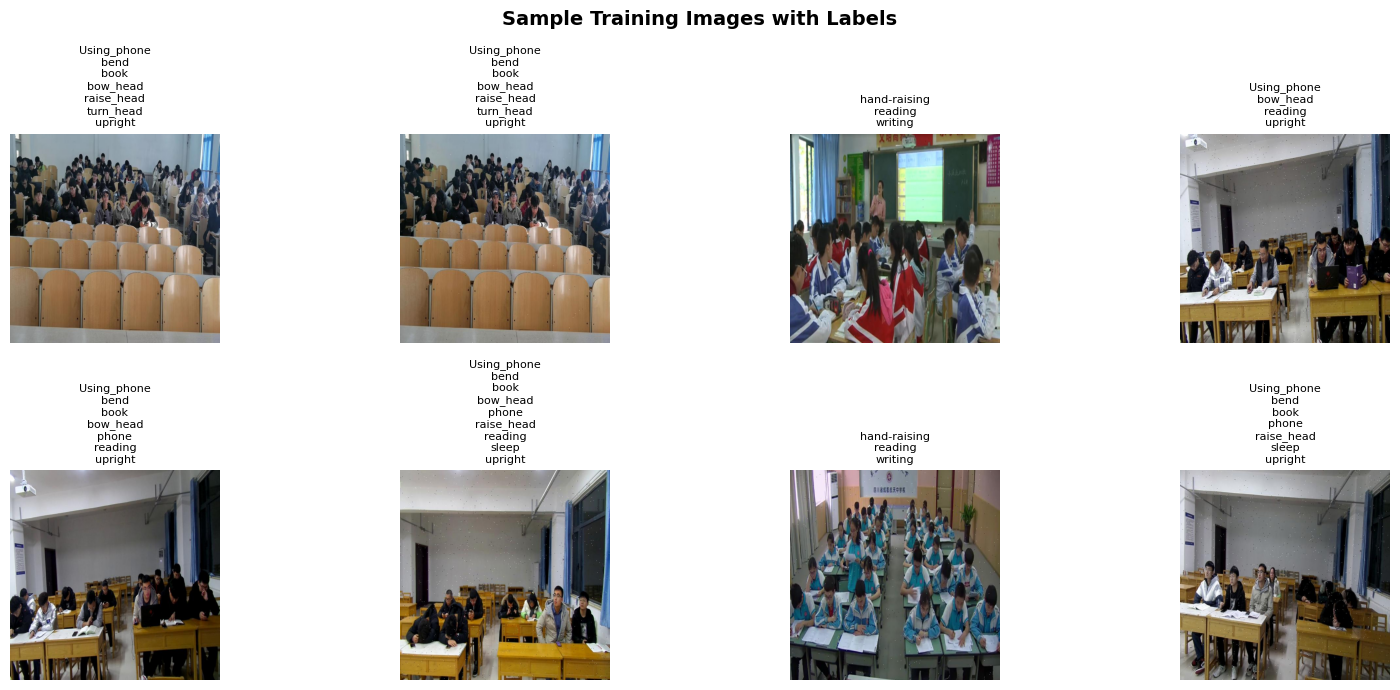

In [ ]:
# Show sample images from training set
import random
from PIL import Image

sample_rows = train_df.sample(8, random_state=42)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, (_, row) in enumerate(sample_rows.iterrows()):
    img_path = os.path.join(DATASET_DIR, 'train', row['filename'])
    img = Image.open(img_path)
    axes[i].imshow(img)
    # Show active labels
    active = [c for c in CLASS_NAMES if row[c] == 1]
    axes[i].set_title('\n'.join(active), fontsize=8)
    axes[i].axis('off')

plt.suptitle('Sample Training Images with Labels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔧 Step 4 — Dataset & DataLoader

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class StudentBehaviourDataset(Dataset):
    def __init__(self, df, img_dir, class_names, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.class_names = class_names
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        labels = torch.tensor(row[self.class_names].values.astype(float), dtype=torch.float32)
        return image, labels

# --- Transforms ---
IMG_SIZE = 224  # EfficientNet standard input size

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])  # ImageNet stats
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# --- Datasets ---
train_dataset = StudentBehaviourDataset(train_df, os.path.join(DATASET_DIR, 'train'), CLASS_NAMES, train_transform)
valid_dataset = StudentBehaviourDataset(valid_df, os.path.join(DATASET_DIR, 'valid'), CLASS_NAMES, val_test_transform)
test_dataset  = StudentBehaviourDataset(test_df,  os.path.join(DATASET_DIR, 'test'),  CLASS_NAMES, val_test_transform)

# --- DataLoaders ---
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ DataLoaders ready")
print(f"   Train batches:      {len(train_loader)}")
print(f"   Validation batches: {len(valid_loader)}")
print(f"   Test batches:       {len(test_loader)}")

# Quick shape check
imgs, labels = next(iter(train_loader))
print(f"\n   Image batch shape:  {imgs.shape}")
print(f"   Label batch shape:  {labels.shape}")

✅ DataLoaders ready
   Train batches:      100
   Validation batches: 19
   Test batches:       10

   Image batch shape:  torch.Size([32, 3, 224, 224])
   Label batch shape:  torch.Size([32, 12])


## 🧠 Step 5 — Build the Model (EfficientNet-B0 + Transfer Learning)

In [ ]:
import torch.nn as nn
from torchvision import models

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

def build_model(num_classes, freeze_backbone=True):
    # Load pretrained EfficientNet-B0
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

    # Freeze backbone layers initially (fine-tune only the classifier)
    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    # Replace classifier head for multi-label classification
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes)
        # No sigmoid here — BCEWithLogitsLoss handles it
    )
    return model

model = build_model(NUM_CLASSES, freeze_backbone=True)
model = model.to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📦 Model: EfficientNet-B0")
print(f"   Total parameters:     {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Output classes:       {NUM_CLASSES}")

Using device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 153MB/s]



📦 Model: EfficientNet-B0
   Total parameters:     4,338,568
   Trainable parameters: 331,020
   Output classes:       12


## ⚙️ Step 6 — Training Setup (Loss, Optimizer, Scheduler)

In [ ]:
import torch.optim as optim

# BCEWithLogitsLoss is perfect for multi-label classification
criterion = nn.BCEWithLogitsLoss()

# Optimizer — only trains the classifier head first
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

# Reduce LR if validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

print("✅ Loss:      BCEWithLogitsLoss (multi-label)")
print("✅ Optimizer: Adam (lr=1e-3)")
print("✅ Scheduler: ReduceLROnPlateau (patience=2)")

✅ Loss:      BCEWithLogitsLoss (multi-label)
✅ Optimizer: Adam (lr=1e-3)
✅ Scheduler: ReduceLROnPlateau (patience=2)


## 🏋️ Step 7 — Training Loop with Checkpointing

In [ ]:
import time

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = torch.sigmoid(outputs) > 0.5  # threshold at 0.5
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
    all_preds  = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    # Subset accuracy (exact match)
    exact_match = (all_preds == all_labels.bool()).all(dim=1).float().mean().item()
    # Per-label accuracy
    per_label_acc = (all_preds == all_labels.bool()).float().mean(dim=0)
    avg_label_acc = per_label_acc.mean().item()
    return total_loss / len(loader.dataset), exact_match, avg_label_acc


# ---- PHASE 1: Train classifier head only (5 epochs) ----
EPOCHS_PHASE1 = 5
history = {'train_loss': [], 'val_loss': [], 'val_exact': [], 'val_acc': []}
best_val_loss = float('inf')
CHECKPOINT = '/content/best_model.pth'

print("="*60)
print("PHASE 1: Training classifier head (backbone frozen)")
print("="*60)

for epoch in range(1, EPOCHS_PHASE1 + 1):
    t0 = time.time()
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_exact, val_acc = evaluate(model, valid_loader, criterion, DEVICE)
    scheduler.step(val_loss)
    elapsed = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_exact'].append(val_exact)
    history['val_acc'].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT)
        saved = '✅ saved'
    else:
        saved = ''

    print(f"Epoch {epoch:02d}/{EPOCHS_PHASE1} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Exact Match: {val_exact:.3f} | "
          f"Label Acc: {val_acc:.3f} | "
          f"{elapsed:.0f}s {saved}")

print("\n✅ Phase 1 complete!")

PHASE 1: Training classifier head (backbone frozen)
Epoch 01/5 | Train Loss: 0.3088 | Val Loss: 0.1895 | Exact Match: 0.305 | Label Acc: 0.918 | 33s ✅ saved
Epoch 02/5 | Train Loss: 0.2005 | Val Loss: 0.1657 | Exact Match: 0.353 | Label Acc: 0.925 | 33s ✅ saved
Epoch 03/5 | Train Loss: 0.1837 | Val Loss: 0.1522 | Exact Match: 0.398 | Label Acc: 0.931 | 35s ✅ saved
Epoch 04/5 | Train Loss: 0.1710 | Val Loss: 0.1554 | Exact Match: 0.368 | Label Acc: 0.926 | 32s 
Epoch 05/5 | Train Loss: 0.1601 | Val Loss: 0.1419 | Exact Match: 0.456 | Label Acc: 0.937 | 32s ✅ saved

✅ Phase 1 complete!


In [ ]:
# ---- PHASE 2: Unfreeze backbone and fine-tune everything ----
print("="*60)
print("PHASE 2: Fine-tuning full model (backbone unfrozen)")
print("="*60)

# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

# Lower learning rate for fine-tuning
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

EPOCHS_PHASE2 = 10

for epoch in range(1, EPOCHS_PHASE2 + 1):
    t0 = time.time()
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_exact, val_acc = evaluate(model, valid_loader, criterion, DEVICE)
    scheduler.step(val_loss)
    elapsed = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_exact'].append(val_exact)
    history['val_acc'].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT)
        saved = '✅ saved'
    else:
        saved = ''

    print(f"Epoch {epoch:02d}/{EPOCHS_PHASE2} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Exact Match: {val_exact:.3f} | "
          f"Label Acc: {val_acc:.3f} | "
          f"{elapsed:.0f}s {saved}")

print(f"\n✅ Training complete! Best val loss: {best_val_loss:.4f}")

PHASE 2: Fine-tuning full model (backbone unfrozen)
Epoch 01/10 | Train Loss: 0.1463 | Val Loss: 0.1315 | Exact Match: 0.503 | Label Acc: 0.944 | 35s ✅ saved
Epoch 02/10 | Train Loss: 0.1277 | Val Loss: 0.1282 | Exact Match: 0.535 | Label Acc: 0.950 | 37s ✅ saved
Epoch 03/10 | Train Loss: 0.1126 | Val Loss: 0.1228 | Exact Match: 0.565 | Label Acc: 0.952 | 37s ✅ saved
Epoch 04/10 | Train Loss: 0.1051 | Val Loss: 0.1272 | Exact Match: 0.573 | Label Acc: 0.954 | 36s 
Epoch 05/10 | Train Loss: 0.0967 | Val Loss: 0.1321 | Exact Match: 0.556 | Label Acc: 0.954 | 38s 
Epoch 06/10 | Train Loss: 0.0895 | Val Loss: 0.1321 | Exact Match: 0.577 | Label Acc: 0.954 | 36s 
Epoch 07/10 | Train Loss: 0.0817 | Val Loss: 0.1281 | Exact Match: 0.590 | Label Acc: 0.956 | 37s 
Epoch 08/10 | Train Loss: 0.0789 | Val Loss: 0.1367 | Exact Match: 0.582 | Label Acc: 0.954 | 37s 
Epoch 09/10 | Train Loss: 0.0743 | Val Loss: 0.1385 | Exact Match: 0.570 | Label Acc: 0.954 | 36s 
Epoch 10/10 | Train Loss: 0.0710 | V

## 📈 Step 8 — Plot Training Curves

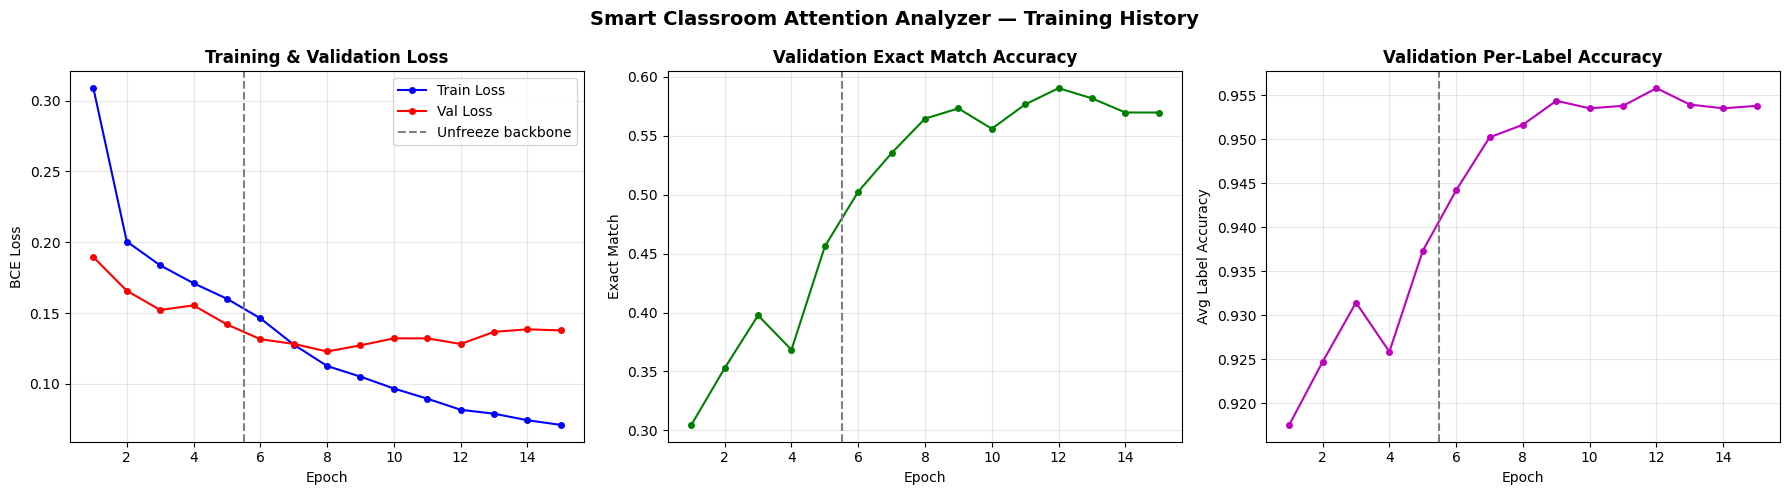

💾 Saved: training_curves.png


In [ ]:
total_epochs = EPOCHS_PHASE1 + EPOCHS_PHASE2
epochs_range = range(1, total_epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
axes[0].axvline(x=EPOCHS_PHASE1 + 0.5, color='gray', linestyle='--', label='Unfreeze backbone')
axes[0].set_title('Training & Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Exact match
axes[1].plot(epochs_range, history['val_exact'], 'g-o', markersize=4)
axes[1].axvline(x=EPOCHS_PHASE1 + 0.5, color='gray', linestyle='--')
axes[1].set_title('Validation Exact Match Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Exact Match')
axes[1].grid(True, alpha=0.3)

# Per-label accuracy
axes[2].plot(epochs_range, history['val_acc'], 'm-o', markersize=4)
axes[2].axvline(x=EPOCHS_PHASE1 + 0.5, color='gray', linestyle='--')
axes[2].set_title('Validation Per-Label Accuracy', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Avg Label Accuracy')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Smart Classroom Attention Analyzer — Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: training_curves.png")

## 🧪 Step 9 — Evaluate on Test Set

In [ ]:
from sklearn.metrics import classification_report, f1_score, hamming_loss

# Load the best saved model
model.load_state_dict(torch.load(CHECKPOINT))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds = (torch.sigmoid(outputs) > 0.5).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# Overall metrics
exact_match   = (all_preds == all_labels).all(axis=1).mean()
hamming       = hamming_loss(all_labels, all_preds)
f1_micro      = f1_score(all_labels, all_preds, average='micro', zero_division=0)
f1_macro      = f1_score(all_labels, all_preds, average='macro', zero_division=0)
f1_weighted   = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print("="*55)
print("           TEST SET RESULTS")
print("="*55)
print(f"  Exact Match Accuracy : {exact_match:.4f} ({exact_match*100:.2f}%)")
print(f"  Hamming Loss         : {hamming:.4f} (lower is better)")
print(f"  F1 Score (Micro)     : {f1_micro:.4f}")
print(f"  F1 Score (Macro)     : {f1_macro:.4f}")
print(f"  F1 Score (Weighted)  : {f1_weighted:.4f}")
print("="*55)

           TEST SET RESULTS
  Exact Match Accuracy : 0.6301 (63.01%)
  Hamming Loss         : 0.0525 (lower is better)
  F1 Score (Micro)     : 0.9565
  F1 Score (Macro)     : 0.7834
  F1 Score (Weighted)  : 0.9557


In [ ]:
# Per-class classification report
print("\nPer-Class Report:")
report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0)
print(report)


Per-Class Report:
              precision    recall  f1-score   support

 Using_phone       0.97      1.00      0.99       272
        bend       0.90      0.98      0.94       223
        book       0.96      1.00      0.98       258
    bow_head       1.00      1.00      1.00       274
hand-raising       0.00      0.00      0.00         0
       phone       0.94      0.93      0.94       193
  raise_head       0.98      0.95      0.96       204
     reading       0.92      0.88      0.90       194
       sleep       0.91      0.88      0.89        91
   turn_head       0.86      0.75      0.80       114
     upright       1.00      1.00      1.00       292
     writing       0.00      0.00      0.00         0

   micro avg       0.96      0.96      0.96      2115
   macro avg       0.79      0.78      0.78      2115
weighted avg       0.96      0.96      0.96      2115
 samples avg       0.96      0.96      0.95      2115



## 🗺️ Step 10 — Confusion Matrix (Per Label)

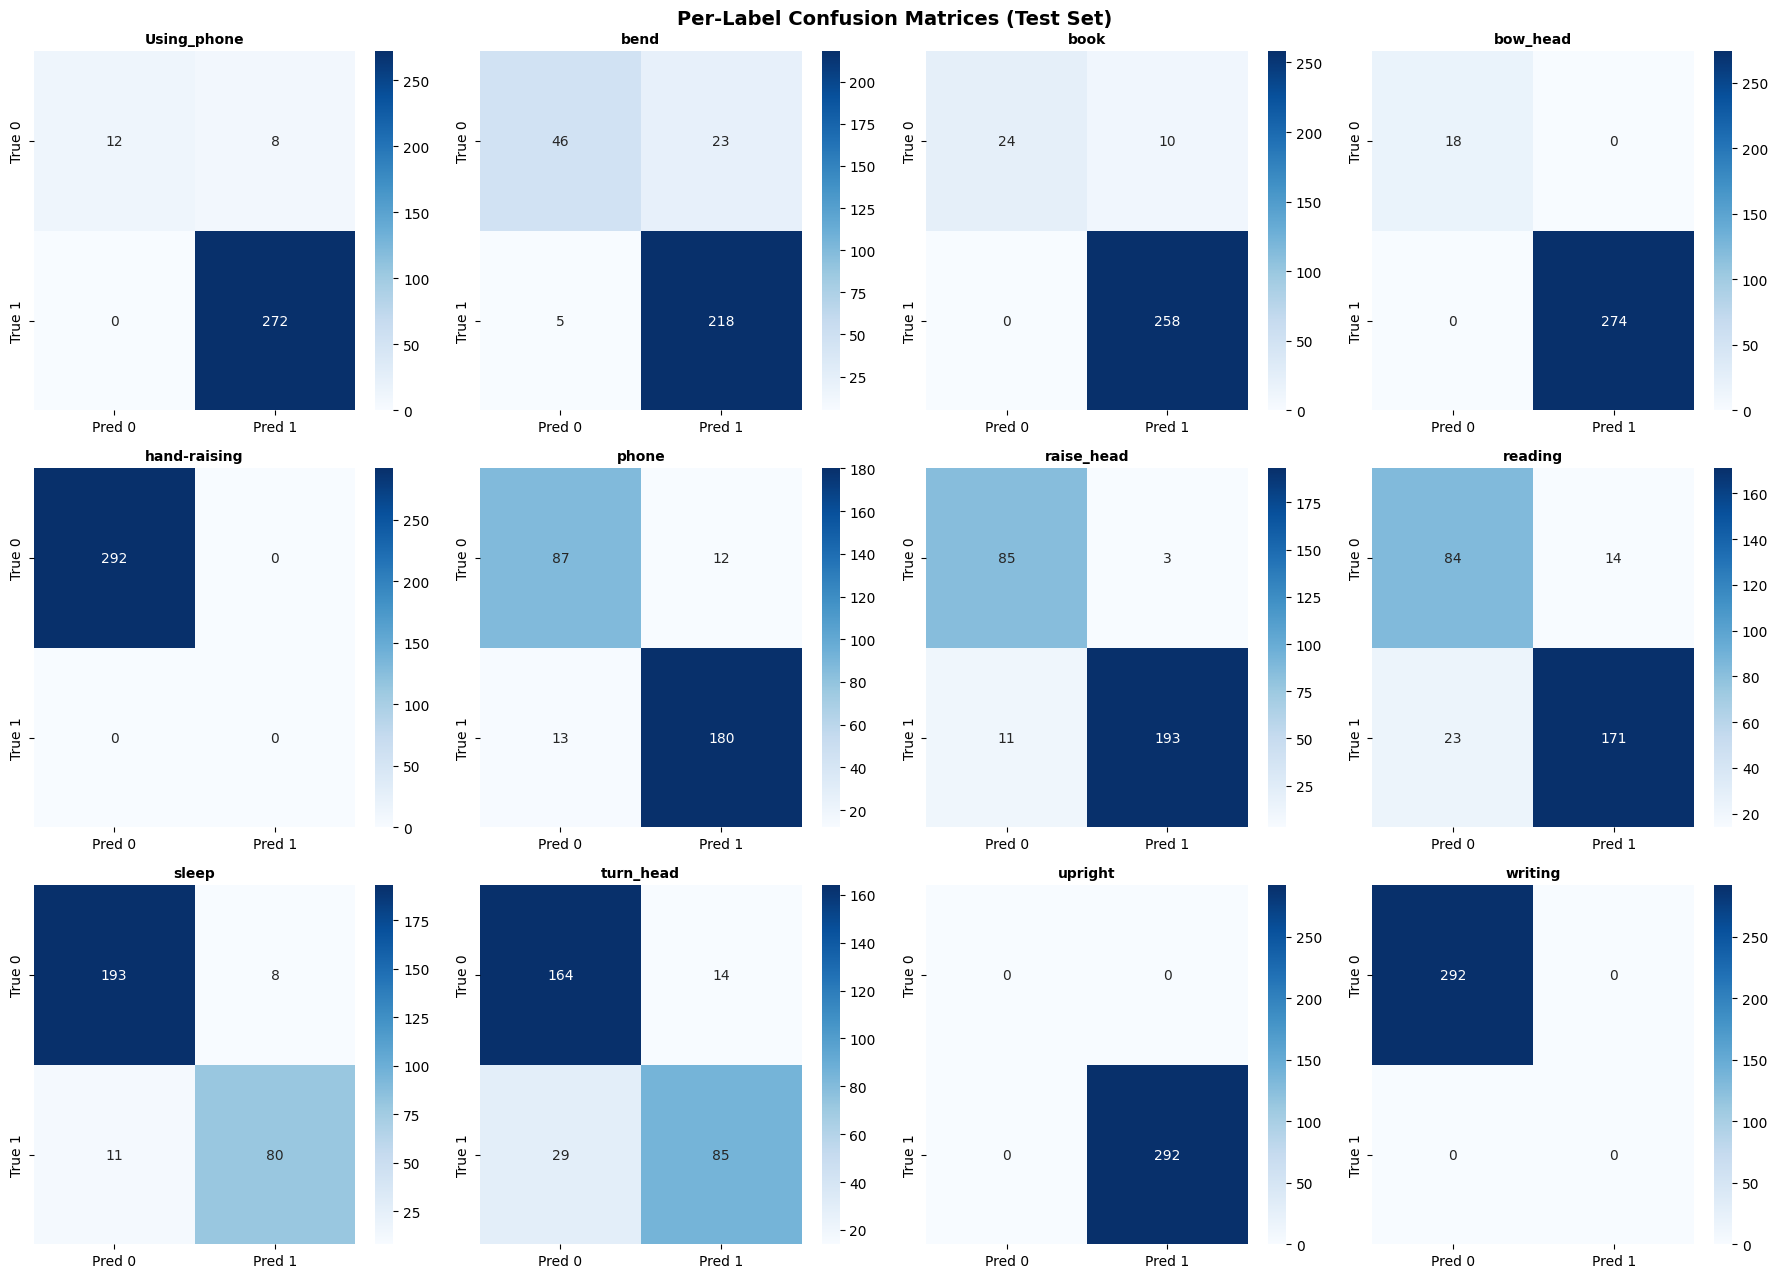

💾 Saved: confusion_matrices.png


In [ ]:
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix

mcm = multilabel_confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(3, 4, figsize=(18, 13))
axes = axes.flatten()

for i, (cm, cls) in enumerate(zip(mcm, CLASS_NAMES)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'])
    axes[i].set_title(cls, fontweight='bold', fontsize=10)

plt.suptitle('Per-Label Confusion Matrices (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: confusion_matrices.png")

## 🔎 Step 11 — Visualise Predictions on Test Images

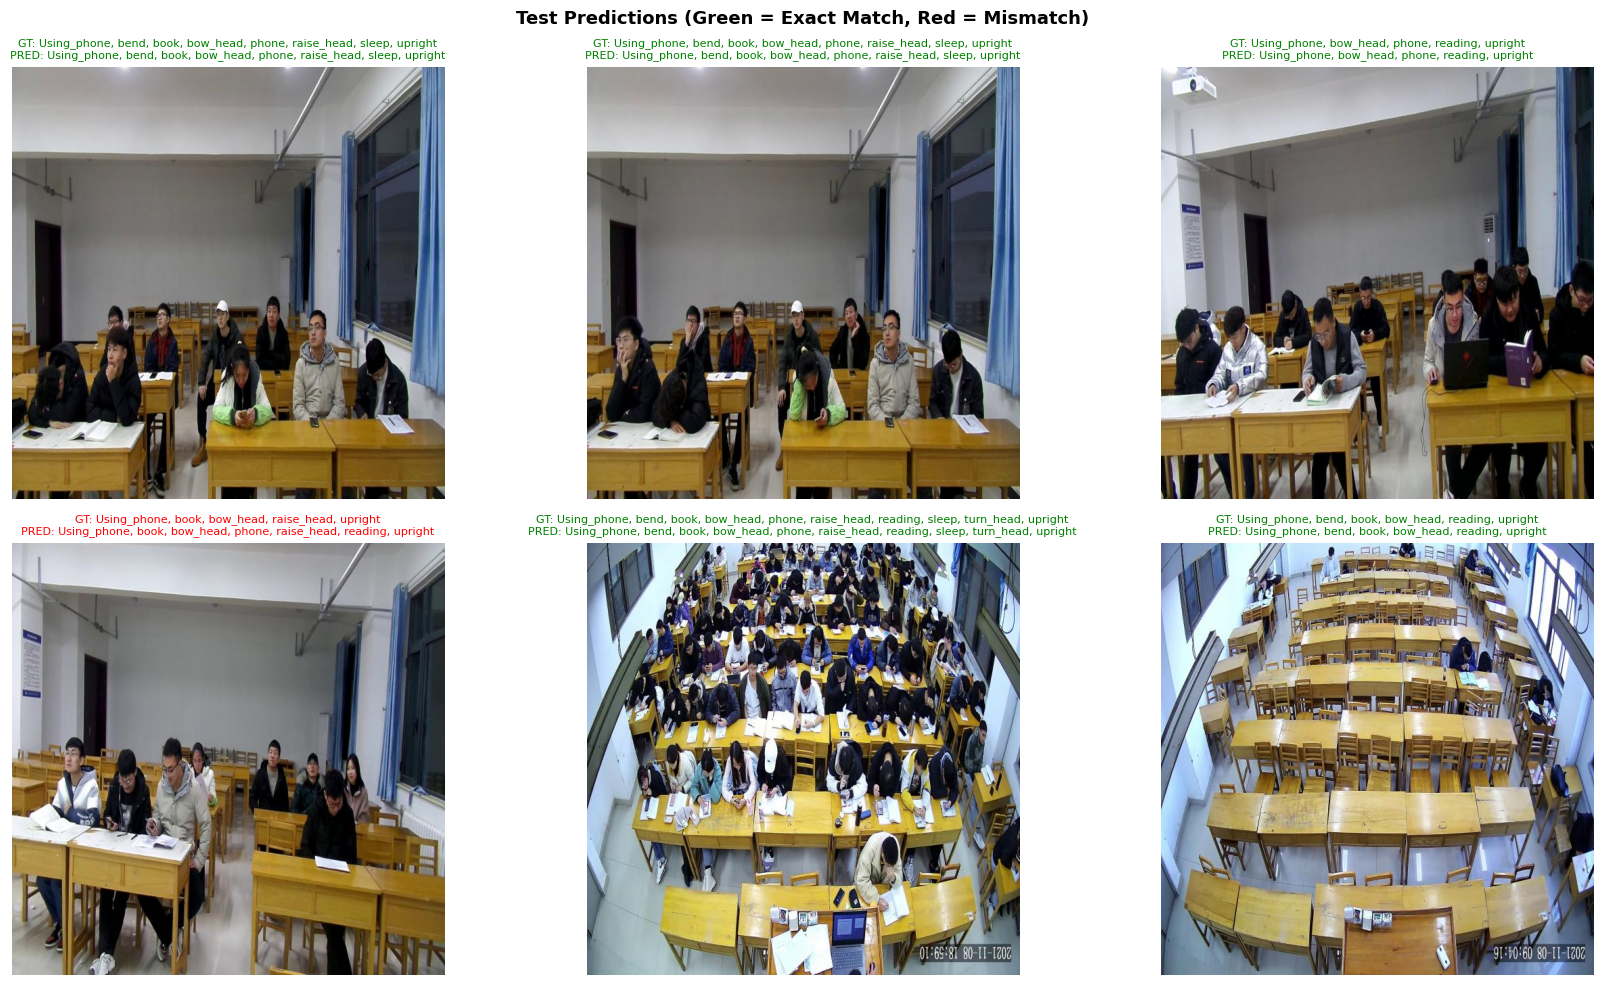

💾 Saved: test_predictions.png


In [ ]:
def predict_image(model, img_path, class_names, transform, device, threshold=0.5):
    """Run inference on a single image and return predicted labels with confidence."""
    img = Image.open(img_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.sigmoid(logits).squeeze().cpu().numpy()
    results = {cls: float(prob) for cls, prob in zip(class_names, probs)}
    predicted = [cls for cls, p in results.items() if p >= threshold]
    return predicted, results

# Show 6 test images with predictions vs ground truth
sample_test = test_df.sample(6, random_state=7)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (_, row) in enumerate(sample_test.iterrows()):
    img_path = os.path.join(DATASET_DIR, 'test', row['filename'])
    predicted, probs = predict_image(model, img_path, CLASS_NAMES, val_test_transform, DEVICE)
    ground_truth = [c for c in CLASS_NAMES if row[c] == 1]

    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')

    gt_str   = 'GT: '   + (', '.join(ground_truth) if ground_truth else 'none')
    pred_str = 'PRED: ' + (', '.join(predicted)     if predicted     else 'none')
    color = 'green' if set(predicted) == set(ground_truth) else 'red'
    axes[i].set_title(f"{gt_str}\n{pred_str}", fontsize=8, color=color)

plt.suptitle('Test Predictions (Green = Exact Match, Red = Mismatch)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: test_predictions.png")

## 💾 Step 12 — Save Model & Download Results

In [ ]:
# Save the final model with metadata
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': CLASS_NAMES,
    'num_classes': NUM_CLASSES,
    'img_size': IMG_SIZE,
    'architecture': 'efficientnet_b0',
    'test_f1_micro': float(f1_micro),
    'test_f1_macro': float(f1_macro),
    'test_exact_match': float(exact_match),
}, '/content/classroom_attention_model.pth')

print("✅ Model saved: classroom_attention_model.pth")
print("\n📥 Downloading results...")

# Download everything
from google.colab import files
files.download('/content/classroom_attention_model.pth')
files.download('/content/training_curves.png')
files.download('/content/confusion_matrices.png')
files.download('/content/test_predictions.png')

✅ Model saved: classroom_attention_model.pth

📥 Downloading results...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🚀 Step 13 — Quick Inference on Any New Image

Upload a classroom image to analyse...


Saving pexels-yankrukov-8199162.jpg to pexels-yankrukov-8199162.jpg


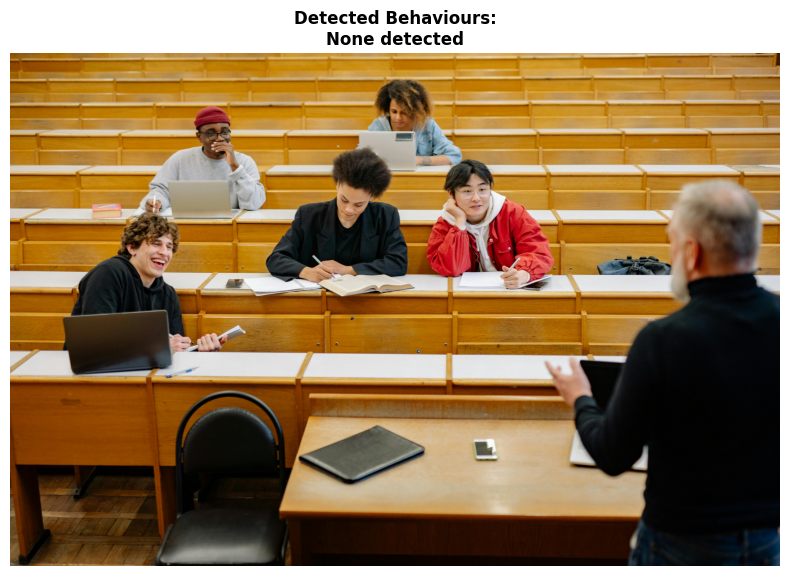


📊 Confidence Scores:
  reading         ████                 0.242
  bow_head        ███                  0.176
  upright         █                    0.083
  bend            █                    0.076
  hand-raising    █                    0.073
  Using_phone                          0.048
  raise_head                           0.027
  book                                 0.025
  writing                              0.024
  phone                                0.006
  sleep                                0.003
  turn_head                            0.003


In [ ]:
# Upload any classroom image and get predictions
print("Upload a classroom image to analyse...")
uploaded_img = files.upload()

for filename in uploaded_img.keys():
    predicted, probs = predict_image(model, filename, CLASS_NAMES, val_test_transform, DEVICE)

    img = Image.open(filename)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')
    title = 'Detected Behaviours:\n' + (', '.join(predicted) if predicted else 'None detected')
    plt.title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\n📊 Confidence Scores:")
    sorted_probs = sorted(probs.items(), key=lambda x: x[1], reverse=True)
    for cls, p in sorted_probs:
        bar = '█' * int(p * 20)
        flag = ' ✅' if p >= 0.5 else ''
        print(f"  {cls:<15} {bar:<20} {p:.3f}{flag}")

In [ ]:
!pip install -q gradio


In [ ]:
import numpy as np

ATTENTION_WEIGHTS = {
    'writing':      +1.0,
    'reading':      +1.0,
    'hand-raising': +1.0,
    'upright':      +0.6,
    'raise_head':   +0.5,
    'book':         +0.4,
    'bow_head':     -0.4,
    'bend':         -0.5,
    'turn_head':    -0.6,
    'sleep':        -1.0,
    'phone':        -1.0,
    'Using_phone':  -1.0,
}

def compute_attention_score(probs_dict):
    score = 0.0
    weight_sum = sum(abs(w) for w in ATTENTION_WEIGHTS.values())
    for label, weight in ATTENTION_WEIGHTS.items():
        prob = probs_dict.get(label, 0.0)
        score += weight * prob
    normalised = (score / weight_sum + 1) / 2 * 100
    return round(float(np.clip(normalised, 0, 100)), 1)

def attention_label(score):
    if score >= 70:
        return "✅ Attentive", "#22c55e"
    elif score >= 45:
        return "⚠️ Partially Attentive", "#f59e0b"
    else:
        return "❌ Inattentive", "#ef4444"

print("✅ Attention scoring ready")

✅ Attention scoring ready


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import torch
import torchvision.transforms as transforms

def run_inference(pil_image):
    transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    model.eval()
    with torch.no_grad():
        tensor = transform(pil_image.convert('RGB')).unsqueeze(0).to(DEVICE)
        outputs = model(tensor)
        probs = torch.sigmoid(outputs).squeeze().cpu().numpy()
    return dict(zip(CLASS_NAMES, probs))

def make_confidence_chart(probs_dict, threshold=0.5):
    labels = list(probs_dict.keys())
    values = list(probs_dict.values())
    colors = ['#22c55e' if v >= threshold else '#94a3b8' for v in values]
    sorted_pairs = sorted(zip(values, labels, colors), reverse=True)
    values, labels, colors = zip(*sorted_pairs)

    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.barh(labels, values, color=colors, edgecolor='white', height=0.6)
    ax.axvline(x=threshold, color='#ef4444', linestyle='--', linewidth=1.5, label=f'Threshold ({threshold})')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Confidence', fontsize=11)
    ax.set_title('Behaviour Confidence Scores', fontsize=13, fontweight='bold')
    for bar, val in zip(bars, values):
        ax.text(min(val + 0.02, 0.93), bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=8,
                color='darkgreen' if val >= threshold else 'black', fontweight='bold')
    detected_patch = mpatches.Patch(color='#22c55e', label='Detected (>=threshold)')
    not_det_patch  = mpatches.Patch(color='#94a3b8', label='Not detected')
    ax.legend(handles=[detected_patch, not_det_patch], loc='lower right', fontsize=9)
    ax.invert_yaxis()
    fig.tight_layout()
    return fig

def make_attention_gauge(score):
    label, color = attention_label(score)
    fig, ax = plt.subplots(figsize=(5, 2.5))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 1)
    ax.barh(0.5, 100, height=0.4, color='#e2e8f0', align='center')
    ax.barh(0.5, min(score, 45), height=0.4, color='#ef4444', align='center')
    if score > 45:
        ax.barh(0.5, min(score - 45, 25), left=45, height=0.4, color='#f59e0b', align='center')
    if score > 70:
        ax.barh(0.5, score - 70, left=70, height=0.4, color='#22c55e', align='center')
    ax.text(50, 0.5, f'{score}%', ha='center', va='center',
            fontsize=22, fontweight='bold', color='white')
    ax.text(50, 0.05, label, ha='center', va='bottom', fontsize=13,
            fontweight='bold', color=color)
    ax.set_title('Attention Score', fontsize=13, fontweight='bold', pad=8)
    ax.axis('off')
    fig.tight_layout()
    return fig

print("✅ Inference and plot functions ready")

✅ Inference and plot functions ready


In [ ]:
import gradio as gr
import os
import pandas as pd

DATASET_DIR = "/content/dataset"
test_df = pd.read_csv(os.path.join(DATASET_DIR, 'test', '_classes.csv'))
test_df.columns = test_df.columns.str.strip()

def analyze_classroom(image, threshold):
    if image is None:
        return None, None, "Please upload an image."

    probs   = run_inference(image)
    score   = compute_attention_score(probs)
    label, color = attention_label(score)
    detected = [cls for cls, p in probs.items() if p >= threshold]

    summary  = f"### {label}\n"
    summary += f"**Attention Score: {score}%**\n\n"
    summary += "**Detected Behaviours:**\n"
    if detected:
        for d in detected:
            summary += f"- `{d}` ({probs[d]:.2f})\n"
    else:
        summary += "- None detected above threshold\n"

    chart = make_confidence_chart(probs, threshold)
    gauge = make_attention_gauge(score)
    return chart, gauge, summary

with gr.Blocks(title="Smart Classroom Attention Analyzer", theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🎓 Smart Classroom Attention Analyzer
    Upload a classroom image to detect student behaviours and compute an attention score.
    """)

    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(label="📷 Upload Classroom Image", type="pil", height=300)
            threshold_slider = gr.Slider(
                minimum=0.1, maximum=0.9, value=0.5, step=0.05,
                label="Detection Threshold",
                info="Lower = more sensitive, Higher = more confident"
            )
            analyze_btn = gr.Button("🔍 Analyze", variant="primary", size="lg")
            gr.Examples(
                examples=[
                    [os.path.join(DATASET_DIR, 'test', test_df.sample(1, random_state=1)['filename'].values[0]), 0.5],
                    [os.path.join(DATASET_DIR, 'test', test_df.sample(1, random_state=5)['filename'].values[0]), 0.5],
                    [os.path.join(DATASET_DIR, 'test', test_df.sample(1, random_state=9)['filename'].values[0]), 0.5],
                ],
                inputs=[image_input, threshold_slider],
                label="📁 Try a test image"
            )

        with gr.Column(scale=2):
            with gr.Row():
                chart_output = gr.Plot(label="Behaviour Confidence Scores")
                gauge_output = gr.Plot(label="Attention Gauge")
            summary_output = gr.Markdown(label="Summary")

    analyze_btn.click(
        fn=analyze_classroom,
        inputs=[image_input, threshold_slider],
        outputs=[chart_output, gauge_output, summary_output]
    )

    gr.Markdown("""
    ---
    **Model:** EfficientNet-B0 | **Task:** Multi-Label Classification | **Classes:** 12 student behaviours
    """)

demo.launch(share=True, debug=True)

/tmp/ipykernel_13332/663366366.py:31: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="Smart Classroom Attention Analyzer", theme=gr.themes.Soft()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://24bee883c3f9d8aeb5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://24bee883c3f9d8aeb5.gradio.live


In [ ]:
import torch
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU - change runtime!'}")

GPU: Tesla T4


In [ ]:
from google.colab import files
uploaded = files.upload()  # upload your best_model.pth here

Saving best_model.pth to best_model.pth


In [ ]:
import torch
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import numpy as np
import os
import torch.nn as nn

IMAGE_SIZE  = 640
CLASS_NAMES = ['Using_phone', 'bend', 'book', 'bow_head',
               'hand-raising', 'phone', 'raise_head', 'reading',
               'sleep', 'turn_head', 'upright', 'writing']
NUM_CLASSES = len(CLASS_NAMES)
CHECKPOINT  = '/content/best_model.pth'
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Match the exact architecture used during training
model = models.efficientnet_b0(weights=None)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(1280, 256),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(256, NUM_CLASSES)
)

model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()
print(f"✅ Model loaded on {DEVICE}")

✅ Model loaded on cuda
